# Wildfire Model-Ready Dataset - EDA

## Load The Model-Ready Dataset

In [27]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Show all columns when we display a dataframe.
pd.set_option("display.max_columns", None)

# Make decimals easier to read.
pd.set_option("display.float_format", "{:.4f}".format)

In [28]:
# All the charts share one style, set here once instead of inside each plot.
# "whitegrid" keeps a light horizontal grid, which helps read values without
# drawing attention away from the bars.
sns.set_theme(
    style="whitegrid",
    context="notebook",
    font_scale=1.05,
    rc={
        "figure.dpi": 120,
        "savefig.dpi": 200,
        "axes.titlesize": 13,
        "axes.titleweight": "semibold",
        "axes.titlepad": 12,
        "axes.labelcolor": "#52514e",
        "axes.edgecolor": "#d8d7d2",
        "text.color": "#0b0b0b",
        "xtick.color": "#52514e",
        "ytick.color": "#52514e",
        "grid.color": "#e6e5e0",
        "grid.linewidth": 0.8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.facecolor": "#fcfcfb",
        "axes.facecolor": "#fcfcfb",
    },
)

# Two colours for the two classes, and one colour for charts with a single series.
# Blue and orange stay apart for colour-blind readers, so the class is never
# guessed from the colour alone.
color_no = "#2a78d6"
color_yes = "#eb6834"
color_single = "#2a78d6"

target_palette = {"No": color_no, "Yes": color_yes}

# Positive and negative correlations use the same two colours,
# so the sign is visible before reading the axis.
correlation_palette = {"positive": color_yes, "negative": color_no}

In [29]:
# This is the dataset built at the end of ml_eda.
# It has one row per case: the reference day plus summaries of the days before it.
model_csv_path = Path("Wildfire_Dataset_model_ready.csv")
model_parquet_path = Path("Wildfire_Dataset_model_ready.parquet")

# Check which files exist and how large they are.
pd.Series({
    "csv_exists": model_csv_path.exists(),
    "csv_size_mb": model_csv_path.stat().st_size / (1024 ** 2) if model_csv_path.exists() else 0,
    "parquet_exists": model_parquet_path.exists(),
    "parquet_size_mb": model_parquet_path.stat().st_size / (1024 ** 2) if model_parquet_path.exists() else 0,
})

csv_exists           True
csv_size_mb       91.4451
parquet_exists      False
parquet_size_mb         0
dtype: object

In [30]:
# Load the Parquet file if it is there, because it loads faster and already
# knows that Datetime is a date. Otherwise fall back to the CSV.
if model_parquet_path.exists():
    model_df = pd.read_parquet(model_parquet_path)
else:
    model_df = pd.read_csv(model_csv_path, parse_dates=["Datetime"])

# Look at the first rows.
model_df.head()

,Case_ID,Latitude,Longitude,Datetime,Wildfire,Precipitation_Today,Max_Relative_Humidity_Today,Min_Relative_Humidity_Today,Specific_Humidity_Today,Solar_Radiation_Today,Min_Daily_Temperature_Today,Max_Daily_Temperature_Today,Wind_Speed_Today,Vapor_Pressure_Deficit_Today,Actual_Evapotranspiration_Today,Potential_Evapotranspiration_Today,Precipitation_Average_7_Days,Max_Relative_Humidity_Max_7_Days,Min_Relative_Humidity_Min_7_Days,Specific_Humidity_Average_7_Days,Solar_Radiation_Average_7_Days,Min_Daily_Temperature_Min_7_Days,Max_Daily_Temperature_Max_7_Days,Wind_Speed_Average_7_Days,Vapor_Pressure_Deficit_Average_7_Days,Actual_Evapotranspiration_Average_7_Days,Potential_Evapotranspiration_Average_7_Days,Precipitation_Average_14_Days,Max_Relative_Humidity_Max_14_Days,Min_Relative_Humidity_Min_14_Days,Specific_Humidity_Average_14_Days,Solar_Radiation_Average_14_Days,Min_Daily_Temperature_Min_14_Days,Max_Daily_Temperature_Max_14_Days,Wind_Speed_Average_14_Days,Vapor_Pressure_Deficit_Average_14_Days,Actual_Evapotranspiration_Average_14_Days,Potential_Evapotranspiration_Average_14_Days,Precipitation_Average_30_Days,Max_Relative_Humidity_Max_30_Days,Min_Relative_Humidity_Min_30_Days,Specific_Humidity_Average_30_Days,Solar_Radiation_Average_30_Days,Min_Daily_Temperature_Min_30_Days,Max_Daily_Temperature_Max_30_Days,Wind_Speed_Average_30_Days,Vapor_Pressure_Deficit_Average_30_Days,Actual_Evapotranspiration_Average_30_Days,Potential_Evapotranspiration_Average_30_Days,Precipitation_Average_60_Days,Max_Relative_Humidity_Max_60_Days,Min_Relative_Humidity_Min_60_Days,Specific_Humidity_Average_60_Days,Solar_Radiation_Average_60_Days,Min_Daily_Temperature_Min_60_Days,Max_Daily_Temperature_Max_60_Days,Wind_Speed_Average_60_Days,Vapor_Pressure_Deficit_Average_60_Days,Actual_Evapotranspiration_Average_60_Days,Potential_Evapotranspiration_Average_60_Days
0,1,25.2603,-80.8010,2016-06-09,No,0.0000,100.0000,63.3000,0.0188,347.3000,24.0500,30.8500,4.5000,0.5200,6.9000,6.0000,2.1571,100.0000,55.1000,0.0192,291.0857,23.5500,32.8500,5.7000,0.8829,7.2571,5.9000,7.2929,100.0000,49.3000,0.0178,279.1857,21.3500,32.8500,4.2929,0.8800,6.6071,5.4857,6.9200,100.0000,44.1000,0.0172,306.5500,19.0500,33.6500,3.8167,0.9443,6.8133,5.7767,4.1117,100.0000,29.9000,0.0154,297.9583,14.1500,33.6500,4.3483,0.9318,6.8400,5.6200
1,2,25.2603,-80.8010,2017-06-09,No,7.6000,100.0000,62.3000,0.0187,211.7000,22.8500,31.2500,4.2000,0.6300,5.0000,4.2000,17.8857,100.0000,57.7000,0.0189,227.4143,21.1500,31.7500,5.4857,0.4729,4.8571,4.1286,9.9214,100.0000,45.6000,0.0186,279.5143,21.0500,35.0500,4.7286,0.7450,6.1786,5.2357,5.3767,100.0000,39.9000,0.0174,304.6733,16.8500,35.0500,5.0300,0.8767,7.0033,5.7933,4.6950,100.0000,31.0000,0.0156,296.2850,13.8500,35.0500,5.3917,0.8918,7.0517,5.6867
2,3,25.2603,-80.8010,2015-06-10,No,4.8000,100.0000,62.6000,0.0193,336.1000,21.3500,31.7500,4.4000,0.4700,6.1000,5.5000,11.3571,100.0000,54.5000,0.0170,250.5714,20.3500,32.0500,2.4714,0.7486,5.2714,4.6000,6.3571,100.0000,46.1000,0.0166,252.1500,18.4500,32.1500,3.6071,0.8093,5.7929,4.8500,3.3133,100.0000,46.1000,0.0165,277.7233,18.4500,34.1500,4.2100,0.9117,6.6067,5.4333,5.8400,100.0000,44.4000,0.0160,282.8567,17.5500,34.8500,4.2433,0.9012,6.5767,5.4083
3,4,25.2603,-80.8010,2018-06-09,Yes,18.3000,100.0000,60.4000,0.0175,269.8000,22.1500,30.5500,3.3000,0.6800,5.6000,4.9000,6.2429,100.0000,53.1000,0.0182,356.3143,22.0500,33.4500,3.4143,0.9129,7.4857,6.5429,6.7143,100.0000,53.1000,0.0176,314.1429,20.9500,33.4500,4.7786,0.7514,6.6286,5.6786,8.9400,100.0000,49.3000,0.0165,279.1667,19.6500,33.4500,4.8000,0.7240,6.1167,5.1267,5.4450,100.0000,30.9000,0.0152,290.8917,11.7500,33.4500,4.7533,0.8375,6.5383,5.3583
4,5,25.2603,-80.8010,2014-06-10,No,14.9000,100.0000,59.6000,0.0173,214.4000,21.2500,30.5500,2.6000,0.6400,4.6000,4.1000,10.6429,100.0000,49.9000,0.0179,281.9429,20.1500,33.5500,3.6286,0.7371,5.9286,5.1714,7.9643,100.0000,49.6000,0.0172,273.5571,20.1500,33.5500,4.2786,0.8079,6.2357,5.2286,4.8767,100.0000,41.10

## Basic Shape And Types

In [31]:
# Shape means: number of rows, number of columns.
# One row here is one case, not one day.
model_df.shape

(126799, 60)

In [32]:
# Check each column name and data type.
pd.DataFrame({
    "column": model_df.columns,
    "dtype": model_df.dtypes.astype(str).values,
})

,column,dtype
0,Case_ID,int64
1,Latitude,float64
2,Longitude,float64
3,Datetime,datetime64[ns]
4,Wildfire,object
5,Precipitation_Today,float64
6,Max_Relative_Humidity_Today,float64
7,Min_Relative_Humidity_Today,float64
8,Specific_Humidity_Today,float64
9,Solar_Radiation_Today,float64


In [33]:
# A quick summary of the dataset.
# This also shows how many non-null values each column has.
model_df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126799 entries, 0 to 126798
Data columns (total 60 columns):
 #   Column                                        Non-Null Count   Dtype         
---  ------                                        --------------   -----         
 0   Case_ID                                       126799 non-null  int64         
 1   Latitude                                      126799 non-null  float64       
 2   Longitude                                     126799 non-null  float64       
 3   Datetime                                      126799 non-null  datetime64[ns]
 4   Wildfire                                      126799 non-null  object        
 5   Precipitation_Today                           126456 non-null  float64       
 6   Max_Relative_Humidity_Today                   126456 non-null  float64       
 7   Min_Relative_Humidity_Today                   126456 non-null  float64       
 8   Specific_Humidity_Today                       126456 n

In [34]:
# Split the columns into groups so the rest of the notebook is easier to read.
# The identifier columns describe the case, the rest are the features.
identifier_columns = ["Case_ID", "Latitude", "Longitude", "Datetime"]
target_column = "Wildfire"

# Today columns are the weather on the reference day itself.
today_columns = [column for column in model_df.columns if column.endswith("_Today")]

# History columns summarize the days before the reference day.
history_columns = [
    column
    for column in model_df.columns
    if column.endswith(("_7_Days", "_14_Days", "_30_Days", "_60_Days"))
]

# Every column we would feed to a model.
feature_columns = today_columns + history_columns

pd.Series({
    "identifier_columns": len(identifier_columns),
    "today_columns": len(today_columns),
    "history_columns": len(history_columns),
    "feature_columns": len(feature_columns),
    "total_columns": model_df.shape[1],
})

identifier_columns     4
today_columns         11
history_columns       44
feature_columns       55
total_columns         60
dtype: int64

## Describe The Columns

In [35]:
# Summary statistics for the numeric columns.
# The min and max values help us spot impossible values left over from cleaning.
model_df.describe().T

,count,mean,min,25%,50%,75%,max,std
Case_ID,126799.0000,63400.0000,1.0000,31700.5000,63400.0000,95099.5000,126799.0000,36603.8627
Latitude,126799.0000,39.1436,25.2603,34.6887,38.5316,43.6697,48.9987,5.2674
Longitude,126799.0000,-106.4347,-124.4370,-118.3439,-110.9258,-95.4199,-67.0125,14.5693
Datetime,126799,2018-07-06 17:01:47.688546560,2014-03-01 00:00:00,2015-12-12 00:00:00,2018-02-24 00:00:00,2020-09-29 00:00:00,2025-03-30 00:00:00,NaN
Precipitation_Today,126456.0000,1.6843,0.0000,0.0000,0.0000,0.0000,265.7000,6.1498
Max_Relative_Humidity_Today,126456.0000,75.1843,8.7000,60.5000,78.5000,93.9000,100.0000,20.8993
Min_Relative_Humidity_Today,126456.0000,32.2127,1.0000,18.5000,29.1000,43.5000,100.0000,17.9906
Specific_Humidity_Today,126456.0000,0.0061,0.0002,0.0037,0.0056,0.0077,0.0234,0.0032
Solar_Radiation_Today,126456.0000,221.4544,0.0000,149.2000,226.9000,296.9000,410.1000,86.2955
Min_Daily_Temperature_Today,126456.0000,7.6858,-36.7500,2.3500,8.2500,13.2500,33.2500,8.1116


In [36]:
# Summary for text columns, like the Wildfire target.
model_df.describe(include="object").T

,count,unique,top,freq
Wildfire,126799,2,No,93328


In [37]:
# Describe only the features we would give to a model.
# Latitude, Longitude and Case_ID are left out because their statistics
# say nothing about the weather.
model_df[feature_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Precipitation_Today,126456.0000,1.6843,6.1498,0.0000,0.0000,0.0000,0.0000,265.7000
Max_Relative_Humidity_Today,126456.0000,75.1843,20.8993,8.7000,60.5000,78.5000,93.9000,100.0000
Min_Relative_Humidity_Today,126456.0000,32.2127,17.9906,1.0000,18.5000,29.1000,43.5000,100.0000
Specific_Humidity_Today,126456.0000,0.0061,0.0032,0.0002,0.0037,0.0056,0.0077,0.0234
Solar_Radiation_Today,126456.0000,221.4544,86.2955,0.0000,149.2000,226.9000,296.9000,410.1000
Min_Daily_Temperature_Today,126456.0000,7.6858,8.1116,-36.7500,2.3500,8.2500,13.2500,33.2500
Max_Daily_Temperature_Today,126456.0000,21.9009,9.6153,-27.6500,15.7500,22.8500,28.9500,48.5500
Wind_Speed_Today,126456.0000,3.7689,1.6843,0.3000,2.6000,3.4000,4.6000,17.4000
Vapor_Pressure_Deficit_Today,126456.0000,1.1843,0.8898,0.0000,0.5200,0.9800,1.6300,6.9100
Actual_Evapotranspiration_Today,126456.0000,5.8084,3.0671,0.0000,3.4000,5.6000,7.8000,22.2000


## Missing Values And Duplicates

In [38]:
# Count missing values in each column.
# The cleaning step replaced the invalid 32767 values with NaN, so anything
# missing here comes from that replacement.
missing_values = model_df.isna().sum().to_frame("missing_count")
missing_values["missing_percent"] = missing_values["missing_count"] / len(model_df) * 100

missing_values.sort_values("missing_count", ascending=False).head(20)

,missing_count,missing_percent
Specific_Humidity_Average_14_Days,343,0.2705
Wind_Speed_Average_30_Days,343,0.2705
Max_Daily_Temperature_Max_14_Days,343,0.2705
Wind_Speed_Average_14_Days,343,0.2705
Vapor_Pressure_Deficit_Average_14_Days,343,0.2705
Actual_Evapotranspiration_Average_14_Days,343,0.2705
Potential_Evapotranspiration_Average_14_Days,343,0.2705
Precipitation_Average_30_Days,343,0.2705
Max_Relative_Humidity_Max_30_Days,343,0.2705
Min_Relative_Humidity_Min_30_Days,343,0.2705


In [39]:
# Look at some of the rows behind those counts.
# info() prints how many values are NOT missing, so the missing ones are the
# difference between the row count and that number.
missing_columns = [column for column in model_df.columns if model_df[column].isna().any()]
rows_with_missing = model_df[model_df[missing_columns].isna().any(axis=1)]

print(f"{len(rows_with_missing):,} rows out of {len(model_df):,} have at least one missing value")

# Show the identifiers next to the columns that are actually missing.
rows_with_missing[
    ["Case_ID", "Latitude", "Longitude", "Datetime", "Wildfire"] + missing_columns
].head(10)

343 rows out of 126,799 have at least one missing value


,Case_ID,Latitude,Longitude,Datetime,Wildfire,Precipitation_Today,Max_Relative_Humidity_Today,Min_Relative_Humidity_Today,Specific_Humidity_Today,Solar_Radiation_Today,Min_Daily_Temperature_Today,Max_Daily_Temperature_Today,Wind_Speed_Today,Vapor_Pressure_Deficit_Today,Actual_Evapotranspiration_Today,Potential_Evapotranspiration_Today,Precipitation_Average_7_Days,Max_Relative_Humidity_Max_7_Days,Min_Relative_Humidity_Min_7_Days,Specific_Humidity_Average_7_Days,Solar_Radiation_Average_7_Days,Min_Daily_Temperature_Min_7_Days,Max_Daily_Temperature_Max_7_Days,Wind_Speed_Average_7_Days,Vapor_Pressure_Deficit_Average_7_Days,Actual_Evapotranspiration_Average_7_Days,Potential_Evapotranspiration_Average_7_Days,Precipitation_Average_14_Days,Max_Relative_Humidity_Max_14_Days,Min_Relative_Humidity_Min_14_Days,Specific_Humidity_Average_14_Days,Solar_Radiation_Average_14_Days,Min_Daily_Temperature_Min_14_Days,Max_Daily_Temperature_Max_14_Days,Wind_Speed_Average_14_Days,Vapor_Pressure_Deficit_Average_14_Days,Actual_Evapotranspiration_Average_14_Days,Potential_Evapotranspiration_Average_14_Days,Precipitation_Average_30_Days,Max_Relative_Humidity_Max_30_Days,Min_Relative_Humidity_Min_30_Days,Specific_Humidity_Average_30_Days,Solar_Radiation_Average_30_Days,Min_Daily_Temperature_Min_30_Days,Max_Daily_Temperature_Max_30_Days,Wind_Speed_Average_30_Days,Vapor_Pressure_Deficit_Average_30_Days,Actual_Evapotranspiration_Average_30_Days,Potential_Evapotranspiration_Average_30_Days,Precipitation_Average_60_Days,Max_Relative_Humidity_Max_60_Days,Min_Relative_Humidity_Min_60_Days,Specific_Humidity_Average_60_Days,Solar_Radiation_Average_60_Days,Min_Daily_Temperature_Min_60_Days,Max_Daily_Temperature_Max_60_Days,Wind_Speed_Average_60_Days,Vapor_Pressure_Deficit_Average_60_Days,Actual_Evapotranspiration_Average_60_Days,Potential_Evapotranspiration_Average_60_Days
84420,84421,41.6472,-82.9788,2019-10-03,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
84421,84422,41.6482,-82.9507,2014-09-01,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
84463,84464,41.6573,-82.9460,2022-03-04,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
84711,84712,41.6976,-83.0234,2024-05-01,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
84712,84713,41.6988,-83.0553,2024-10-30,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
84732,84733,41.7012,-82.9337,2021-04-01,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
84765,84766,41.7040,-83.0276,2014-07-13,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
84878,84879,41.7202,-83.1228,2015-08-08,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
84998,84999,41.7408,-82.8407,2

In [40]:
# Count how many rows have at least one missing value.
# This tells us how many cases we would lose if we simply dropped them.
rows_with_missing = model_df.isna().any(axis=1).sum()

pd.Series({
    "columns_with_missing": int((model_df.isna().sum() > 0).sum()),
    "rows_with_missing": int(rows_with_missing),
    "rows_with_missing_percent": rows_with_missing / len(model_df) * 100,
    "total_missing_values": int(model_df.isna().sum().sum()),
})

columns_with_missing           55.0000
rows_with_missing             343.0000
rows_with_missing_percent       0.2705
total_missing_values        18865.0000
dtype: float64

In [41]:
# Check for duplicated rows and duplicated cases.
# Case_ID should be unique, because the dataset has one row per case.
pd.Series({
    "duplicate_rows": model_df.duplicated().sum(),
    "duplicate_case_ids": model_df.duplicated(subset=["Case_ID"]).sum(),
    "duplicate_location_dates": model_df.duplicated(subset=["Latitude", "Longitude", "Datetime"]).sum(),
})

duplicate_rows               0
duplicate_case_ids           0
duplicate_location_dates    14
dtype: int64

In [42]:
# Check that no invalid 32767 values survived the cleaning step.
pd.Series({
    "remaining_32767_values": int(model_df[feature_columns].eq(32767).sum().sum()),
})

remaining_32767_values    0
dtype: int64

## The Target

In [43]:
# Check if the target is balanced or imbalanced.
# An imbalanced target changes which metrics we can trust later.
wildfire_counts = model_df[target_column].value_counts(dropna=False).to_frame("count")
wildfire_counts["percent"] = model_df[target_column].value_counts(normalize=True, dropna=False) * 100

wildfire_counts

,count,percent
Wildfire,,
No,93328,73.6031
Yes,33471,26.3969


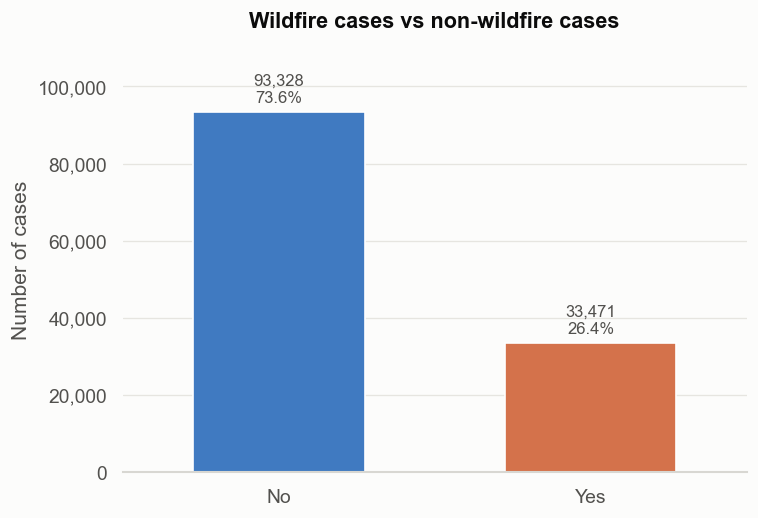

In [44]:
# Same information as a bar chart, because the imbalance is easier to see.
# The count is written on top of each bar, so the chart does not need a
# second look at the y axis.
figure, axis = plt.subplots(figsize=(6.5, 4.5))

sns.barplot(
    x=wildfire_counts.index,
    y=wildfire_counts["count"],
    hue=wildfire_counts.index,
    palette=target_palette,
    legend=False,
    width=0.55,
    ax=axis,
)

# Write the count and the percentage above each bar.
for patch, (label, row) in zip(axis.patches, wildfire_counts.iterrows()):
    axis.annotate(
        f"{int(row['count']):,}\n{row['percent']:.1f}%",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        color="#52514e",
        xytext=(0, 4),
        textcoords="offset points",
    )

axis.set_title("Wildfire cases vs non-wildfire cases")
axis.set_xlabel("")
axis.set_ylabel("Number of cases")

# Give the labels room at the top of the chart.
axis.set_ylim(0, wildfire_counts["count"].max() * 1.18)

# Thousands separators, so the axis reads the same way as the labels.
axis.yaxis.set_major_formatter(lambda value, _: f"{value:,.0f}")

# Only a horizontal grid, because the bars are vertical.
axis.grid(axis="x", visible=False)
sns.despine(ax=axis, left=True)

plt.tight_layout()
plt.show()

## Cases, Locations And Dates

In [45]:
# Check the time period covered by the reference days.
pd.Series({
    "min_date": model_df["Datetime"].min(),
    "max_date": model_df["Datetime"].max(),
    "unique_dates": model_df["Datetime"].nunique(),
})

min_date        2014-03-01 00:00:00
max_date        2025-03-30 00:00:00
unique_dates                   4033
dtype: object

In [46]:
# Count how many cases each location has.
# A location is defined by Latitude and Longitude together.
# A location can appear more than once, because it can have several windows.
cases_per_location = model_df.groupby(["Latitude", "Longitude"]).size()

pd.Series({
    "total_cases": model_df["Case_ID"].nunique(),
    "unique_locations": cases_per_location.shape[0],
    "locations_with_multiple_cases": int((cases_per_location > 1).sum()),
    "min_cases_per_location": cases_per_location.min(),
    "median_cases_per_location": cases_per_location.median(),
    "max_cases_per_location": cases_per_location.max(),
})

total_cases                     126799.0000
unique_locations                 37098.0000
locations_with_multiple_cases    23221.0000
min_cases_per_location               1.0000
median_cases_per_location            2.0000
max_cases_per_location              19.0000
dtype: float64

In [47]:
# Count the cases per year, split by the target.
# This shows if the wildfire cases are spread over the whole period
# or concentrated in a few years.
cases_by_year = (
    model_df
    .assign(year=model_df["Datetime"].dt.year)
    .groupby(["year", target_column])
    .size()
    .unstack(fill_value=0)
)

cases_by_year

Wildfire,No,Yes
year,,
2014,13951,1581
2015,14133,2445
2016,12882,2610
2017,11565,2859
2018,10218,2799
2019,8839,2867
2020,7464,3211
2021,6057,3521
2022,4579,3726


In [48]:
# Count the cases per month, split by the target.
# Wildfires are seasonal, so we expect the Yes cases to cluster in some months.
cases_by_month = (
    model_df
    .assign(month=model_df["Datetime"].dt.month)
    .groupby(["month", target_column])
    .size()
    .unstack(fill_value=0)
)

cases_by_month

Wildfire,No,Yes
month,,
1,4703,2198
2,4946,2070
3,8615,2508
4,8406,2712
5,8664,2989
6,8715,3195
7,10369,3563
8,10550,3432
9,8891,3057


## First Look At The Features

In [49]:
# Compare the average of each feature for wildfire and non-wildfire cases.
# A large difference is an early hint that the feature is useful.
feature_means_by_target = model_df.groupby(target_column)[feature_columns].mean().T
feature_means_by_target.columns = [f"mean_{column}" for column in feature_means_by_target.columns]

# The difference column makes the comparison easier to read.
if {"mean_Yes", "mean_No"}.issubset(feature_means_by_target.columns):
    feature_means_by_target["difference"] = (
        feature_means_by_target["mean_Yes"] - feature_means_by_target["mean_No"]
    )

feature_means_by_target

,mean_No,mean_Yes,difference
Precipitation_Today,1.9017,1.0802,-0.8215
Max_Relative_Humidity_Today,76.5131,71.4927,-5.0204
Min_Relative_Humidity_Today,33.7199,28.0255,-5.6944
Specific_Humidity_Today,0.0061,0.0059,-0.0002
Solar_Radiation_Today,219.4059,227.1454,7.7395
Min_Daily_Temperature_Today,7.3744,8.5510,1.1766
Max_Daily_Temperature_Today,21.3636,23.3935,2.0299
Wind_Speed_Today,3.7994,3.6842,-0.1152
Vapor_Pressure_Deficit_Today,1.1281,1.3403,0.2122
Actual_Evapotranspiration_Today,5.6326,6.2968,0.6642


In [50]:
# Turn the target into 0 and 1 so we can correlate it with the features.
# This is only used for exploring, not for training.
model_df["Wildfire_Binary"] = (model_df[target_column] == "Yes").astype(int)

# Correlation between each feature and the target.
# Values near 0 mean the feature alone tells us very little.
target_correlation = (
    model_df[feature_columns + ["Wildfire_Binary"]]
    .corr(numeric_only=True)["Wildfire_Binary"]
    .drop("Wildfire_Binary")
    .sort_values(ascending=False)
    .to_frame("correlation_with_wildfire")
)

target_correlation

,correlation_with_wildfire
Vapor_Pressure_Deficit_Today,0.1052
Actual_Evapotranspiration_Today,0.0955
Vapor_Pressure_Deficit_Average_7_Days,0.0944
Max_Daily_Temperature_Today,0.0931
Vapor_Pressure_Deficit_Average_14_Days,0.0898
Vapor_Pressure_Deficit_Average_60_Days,0.0869
Vapor_Pressure_Deficit_Average_30_Days,0.0855
Potential_Evapotranspiration_Today,0.0807
Max_Daily_Temperature_Max_60_Days,0.0759
Max_Daily_Temperature_Max_7_Days,0.0705


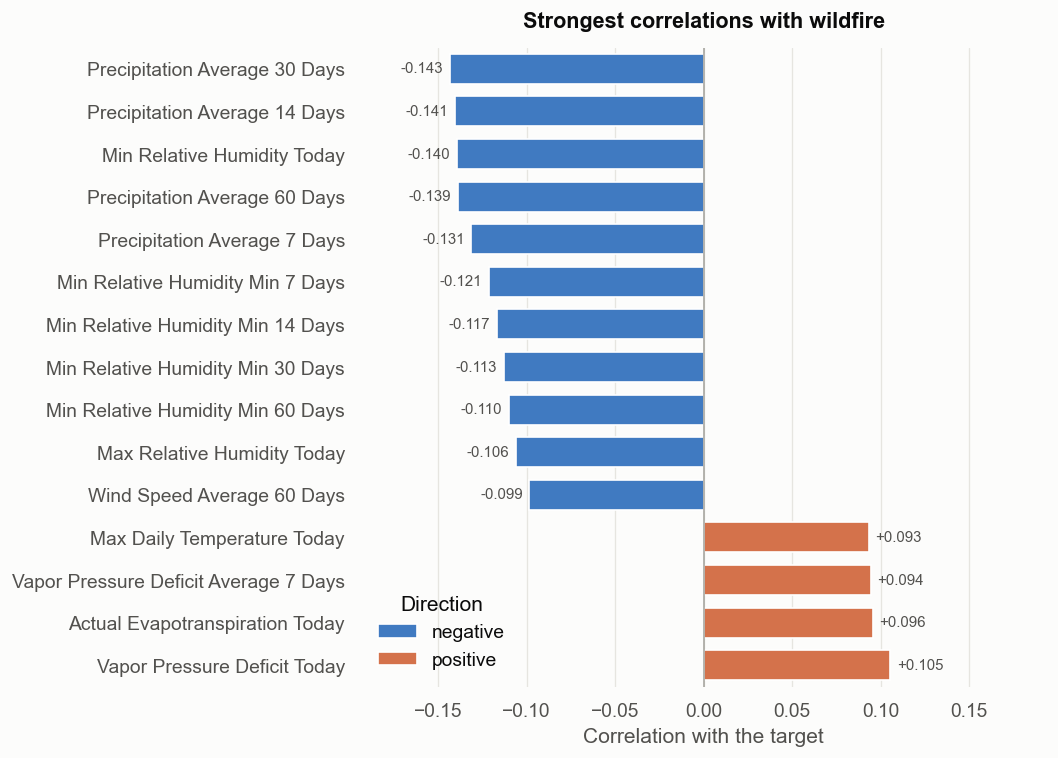

In [51]:
# The 15 strongest correlations, positive or negative, as a bar chart.
strongest_correlations = (
    target_correlation["correlation_with_wildfire"]
    .reindex(target_correlation["correlation_with_wildfire"].abs().sort_values(ascending=False).index)
    .head(15)
    .sort_values()
    .to_frame("correlation")
)

# Colour by the sign, so a feature that pushes towards a wildfire looks
# different from one that pushes away from it.
strongest_correlations["direction"] = [
    "positive" if value > 0 else "negative"
    for value in strongest_correlations["correlation"]
]

# Column names are long, so make them readable on the axis.
strongest_correlations["label"] = [
    name.replace("_", " ") for name in strongest_correlations.index
]

figure, axis = plt.subplots(figsize=(9, 6.5))

sns.barplot(
    data=strongest_correlations,
    x="correlation",
    y="label",
    hue="direction",
    palette=correlation_palette,
    dodge=False,
    width=0.7,
    ax=axis,
)

# Write the value at the end of each bar instead of making the reader
# follow it back to the axis.
for patch, value in zip(axis.patches, strongest_correlations["correlation"]):
    axis.annotate(
        f"{value:+.3f}",
        (patch.get_width(), patch.get_y() + patch.get_height() / 2),
        ha="left" if value >= 0 else "right",
        va="center",
        fontsize=9,
        color="#52514e",
        xytext=(4 if value >= 0 else -4, 0),
        textcoords="offset points",
    )

# A line at zero, because the bars go both ways.
axis.axvline(0, color="#a8a7a1", linewidth=1)

axis.set_title("Strongest correlations with wildfire")
axis.set_xlabel("Correlation with the target")
axis.set_ylabel("")
axis.legend(title="Direction", frameon=False, loc="lower left")

# Leave space on both sides for the value labels.
limit = strongest_correlations["correlation"].abs().max() * 1.35
axis.set_xlim(-limit, limit)

axis.grid(axis="y", visible=False)
sns.despine(ax=axis, left=True, bottom=True)

plt.tight_layout()
plt.show()

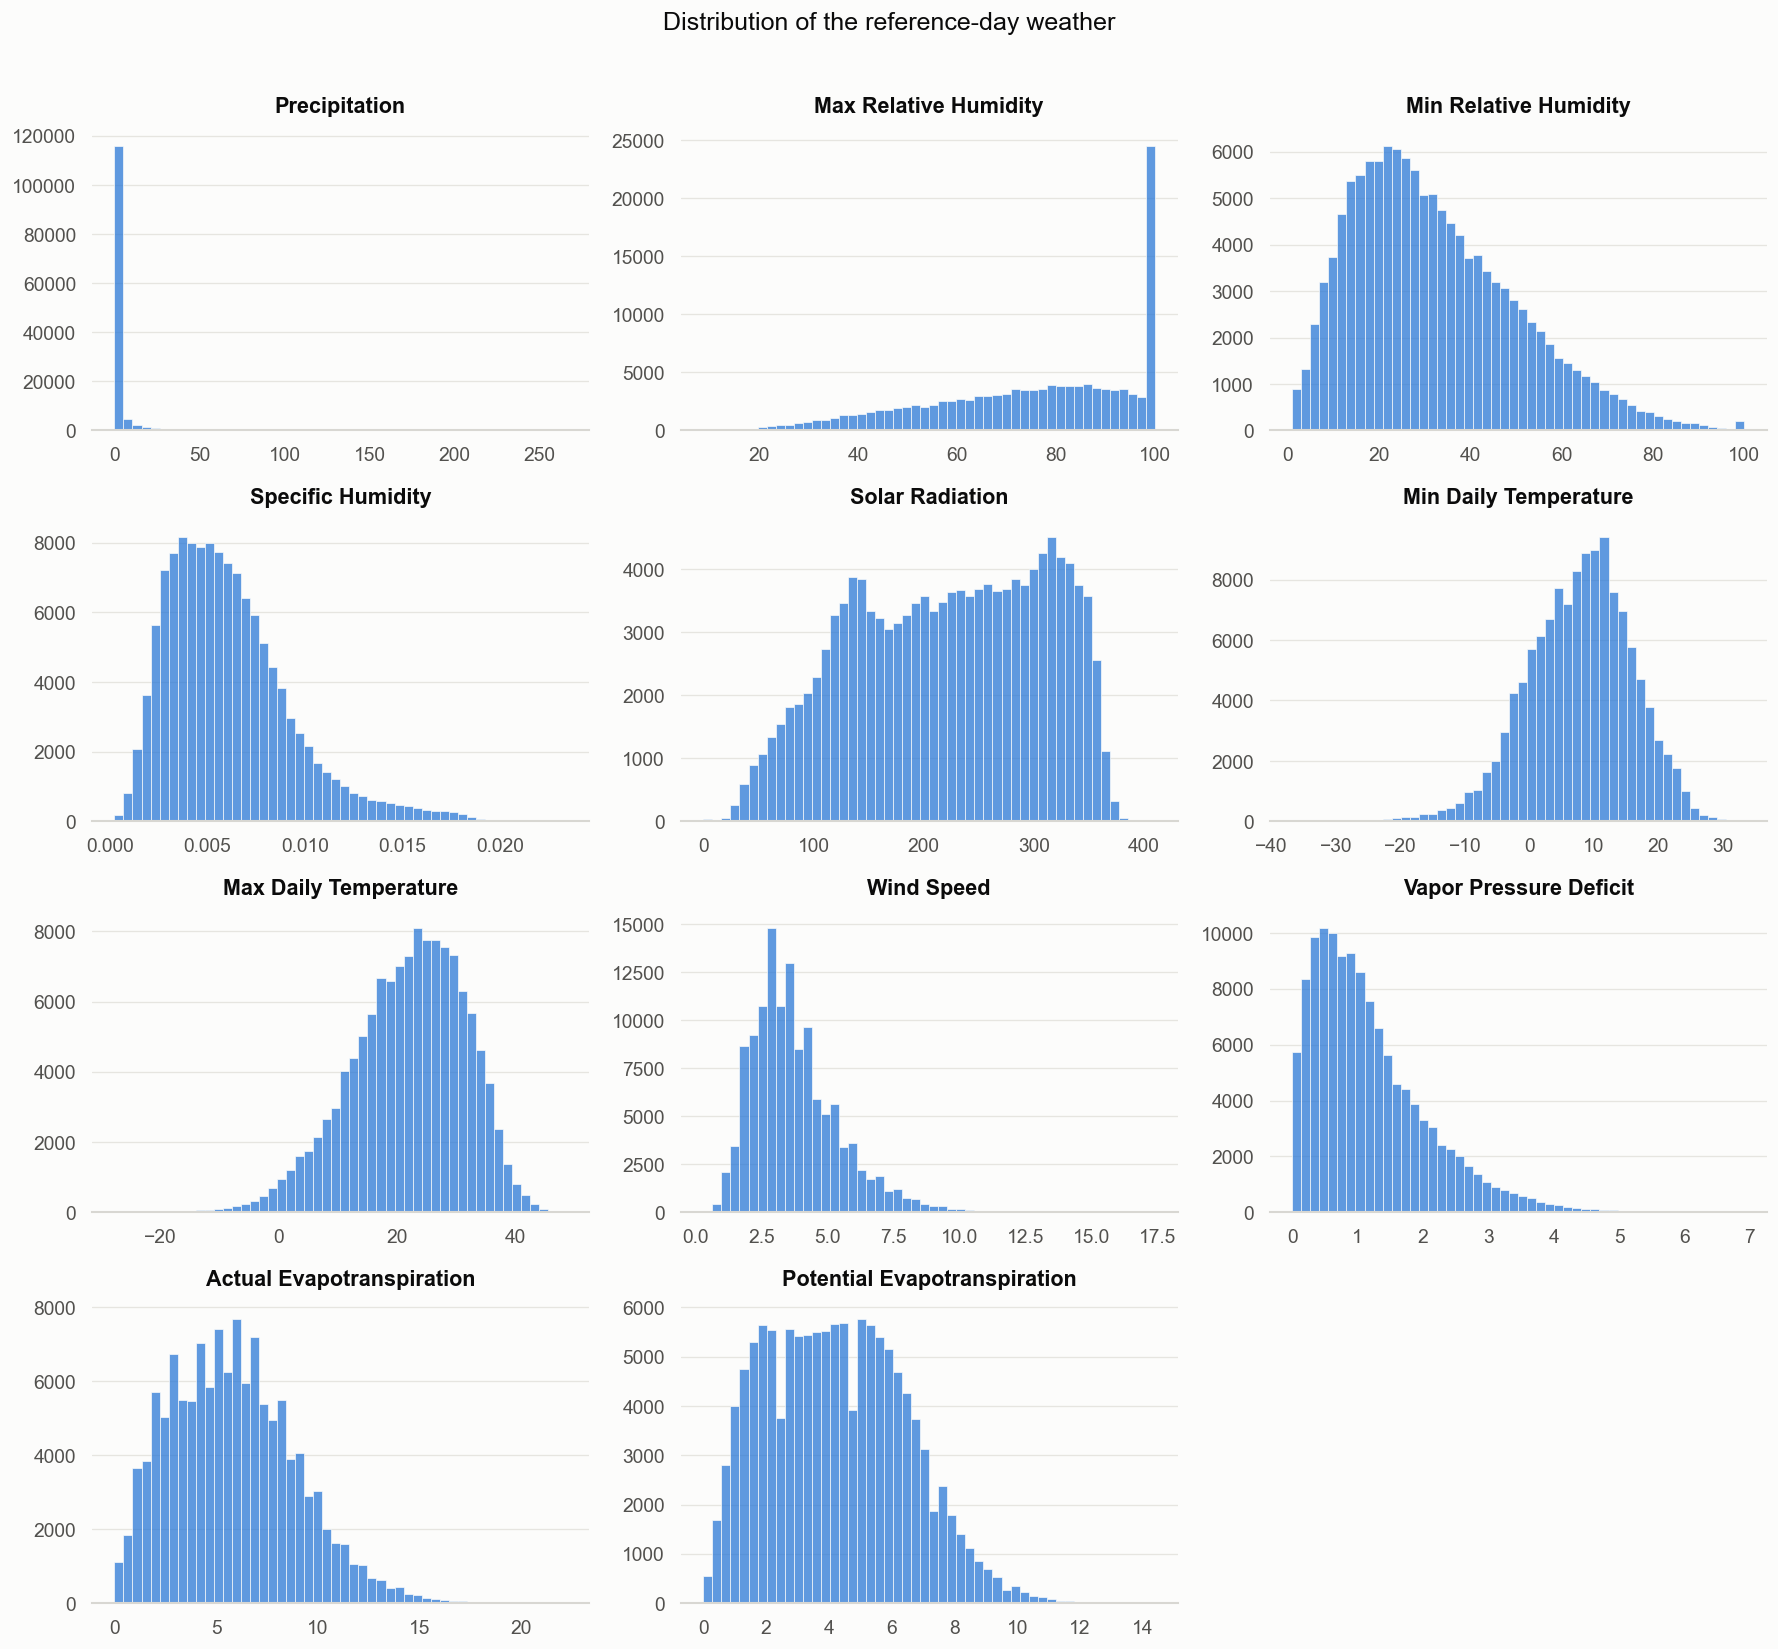

In [52]:
# Look at the distribution of the reference-day weather columns.
# One histogram per column, so we can spot skew and strange values.
# These are all the same measure repeated, so they share one colour.
columns_per_row = 3
rows_needed = -(-len(today_columns) // columns_per_row)

figure, axes = plt.subplots(
    rows_needed,
    columns_per_row,
    figsize=(15, 3.4 * rows_needed),
)

for axis, column in zip(axes.flatten(), today_columns):
    sns.histplot(
        data=model_df,
        x=column,
        bins=50,
        color=color_single,
        edgecolor="#fcfcfb",
        linewidth=0.4,
        ax=axis,
    )
    axis.set_title(column.replace("_Today", "").replace("_", " "))
    axis.set_xlabel("")
    axis.set_ylabel("")
    axis.grid(axis="x", visible=False)
    sns.despine(ax=axis, left=True)

# Hide the leftover empty panels in the last row.
for axis in axes.flatten()[len(today_columns):]:
    axis.set_visible(False)

figure.suptitle("Distribution of the reference-day weather", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# The Precipitation histogram has a long right tail, so look at the rows behind it.
# Precipitation is in millimetres of rain on the reference day, and most days are dry,
# which is why almost every case sits in the first bar.
precipitation_column = "Precipitation_Today"

# How far the tail reaches, in percentiles.
precipitation_tail = model_df[precipitation_column].quantile([0.5, 0.9, 0.99, 0.999, 1.0]).to_frame("precipitation_mm")
precipitation_tail["cases_above"] = [
    int((model_df[precipitation_column] > value).sum())
    for value in precipitation_tail["precipitation_mm"]
]

precipitation_tail

In [ ]:
# The 15 wettest reference days, with their identifiers, so we can check them.
# 265.7 mm in Louisiana on 2016-03-09 matches the real March 2016 flood there,
# so these are extreme weather, not leftover invalid values.
wettest_cases = model_df.nlargest(15, precipitation_column)[
    identifier_columns + [target_column, precipitation_column]
]

wettest_cases

In [ ]:
# Same view for the history columns, one grid per window.
# Each window summarises the days before the reference day, so a wide 30-day
# summary should look smoother than the single reference day.
history_windows = ["7_Days", "14_Days", "30_Days"]

for window in history_windows:
    window_columns = [column for column in history_columns if column.endswith(window)]

    columns_per_row = 3
    rows_needed = -(-len(window_columns) // columns_per_row)

    figure, axes = plt.subplots(
        rows_needed,
        columns_per_row,
        figsize=(15, 3.4 * rows_needed),
    )

    for axis, column in zip(axes.flatten(), window_columns):
        sns.histplot(
            data=model_df,
            x=column,
            bins=50,
            color=color_single,
            edgecolor="#fcfcfb",
            linewidth=0.4,
            ax=axis,
        )
        # The title keeps the summary word (Average, Max, Median) because it is
        # the difference between these columns and the reference-day ones.
        axis.set_title(column.replace(f"_{window}", "").replace("_", " "))
        axis.set_xlabel("")
        axis.set_ylabel("")
        axis.grid(axis="x", visible=False)
        sns.despine(ax=axis, left=True)

    # Hide the leftover empty panels in the last row.
    for axis in axes.flatten()[len(window_columns):]:
        axis.set_visible(False)

    figure.suptitle(
        f"Distribution of the weather over the {window.replace('_Days', '')} days before",
        fontsize=15,
        y=1.01,
    )
    plt.tight_layout()
    plt.show()

In [ ]:
# Put every window on top of each other, one panel per measure.
# The grids above show one window at a time, so they cannot answer whether a
# longer window shifts or narrows the distribution. Overlapping them can.
overlay_windows = ["Today", "7_Days", "14_Days", "30_Days"]

# One hue per window, going from blue to orange as the window gets longer,
# so the order is readable without checking the legend every time.
window_palette = {
    "Today": "#2a78d6",
    "7_Days": "#17a398",
    "14_Days": "#e5a114",
    "30_Days": "#eb6834",
}

# Group the columns by the measure they describe, ignoring the window suffix
# and the summary word (Average, Max, Median).
measures = [column.replace("_Today", "") for column in today_columns]

columns_per_row = 3
rows_needed = -(-len(measures) // columns_per_row)

figure, axes = plt.subplots(
    rows_needed,
    columns_per_row,
    figsize=(15, 3.6 * rows_needed),
)

for axis, measure in zip(axes.flatten(), measures):
    for window in overlay_windows:
        if window == "Today":
            column = f"{measure}_Today"
        else:
            # The history name keeps its summary word, so match on both ends.
            matches = [
                candidate
                for candidate in history_columns
                if candidate.startswith(f"{measure}_") and candidate.endswith(window)
            ]
            if not matches:
                continue
            column = matches[0]

        # Density instead of counts, because the windows have the same number of
        # rows but very different spreads, and outlines instead of bars, because
        # filled bars would hide each other.
        sns.histplot(
            data=model_df,
            x=column,
            bins=50,
            stat="density",
            common_norm=False,
            element="step",
            fill=False,
            color=window_palette[window],
            linewidth=1.4,
            label=window.replace("_Days", " days"),
            ax=axis,
        )

    axis.set_title(measure.replace("_", " "))
    axis.set_xlabel("")
    axis.set_ylabel("")
    axis.grid(axis="x", visible=False)
    sns.despine(ax=axis, left=True)

# Hide the leftover empty panels in the last row.
for axis in axes.flatten()[len(measures):]:
    axis.set_visible(False)

# One legend for the whole figure, not one per panel.
handles, labels = axes.flatten()[0].get_legend_handles_labels()
figure.legend(handles, labels, loc="lower center", ncol=len(overlay_windows), frameon=False)

figure.suptitle("Every window on top of each other, per measure", fontsize=15, y=1.01)
plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

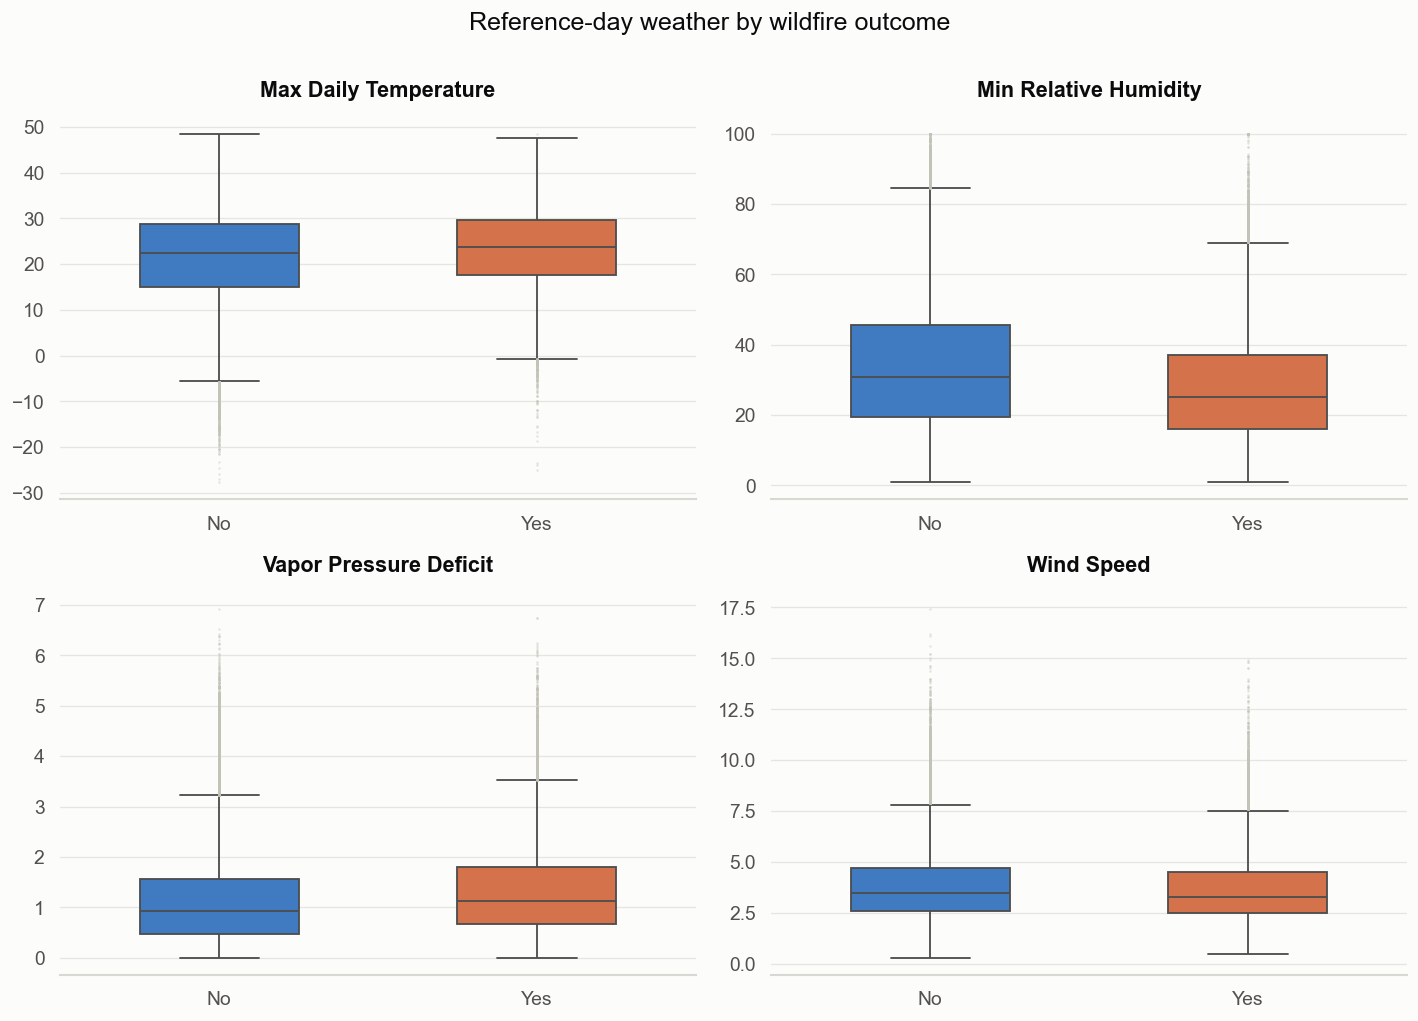

In [53]:
# Compare a few reference-day features between wildfire and non-wildfire cases.
# Boxplots show the difference in the middle of the data, not only the average.
columns_to_compare = [
    "Max_Daily_Temperature_Today",
    "Min_Relative_Humidity_Today",
    "Vapor_Pressure_Deficit_Today",
    "Wind_Speed_Today",
]

figure, axes = plt.subplots(2, 2, figsize=(12, 8.5))

for axis, column in zip(axes.flatten(), columns_to_compare):
    sns.boxplot(
        data=model_df,
        x=target_column,
        y=column,
        hue=target_column,
        palette=target_palette,
        legend=False,
        width=0.5,
        linewidth=1.1,
        fliersize=1.5,
        # Grey outliers so the coloured box stays the thing we read first.
        flierprops={"marker": "o", "markerfacecolor": "#c3c2b7", "markeredgecolor": "none", "alpha": 0.4},
        ax=axis,
    )
    axis.set_title(column.replace("_Today", "").replace("_", " "))
    axis.set_xlabel("")
    axis.set_ylabel("")
    axis.grid(axis="x", visible=False)
    sns.despine(ax=axis, left=True)

figure.suptitle("Reference-day weather by wildfire outcome", fontsize=15, y=1.0)
plt.tight_layout()
plt.show()

## Where The Cases Are On The Map

In [ ]:
# State outlines for the background of the maps.
# The file is kept next to the notebook so the maps also work offline; if it is
# missing we download it once and save it.
import geopandas as gpd

states_path = Path("us_states.geojson")
states_url = "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"

if not states_path.exists():
    gpd.read_file(states_url).to_file(states_path, driver="GeoJSON")

us_states = gpd.read_file(states_path)

# The cases only cover the mainland, so Alaska and Hawaii would leave the map
# mostly empty. Drop them and keep the mainland box.
mainland_states = us_states[~us_states["name"].isin(["Alaska", "Hawaii", "Puerto Rico"])]

pd.Series({
    "states_in_file": len(us_states),
    "states_drawn": len(mainland_states),
    "min_latitude": model_df["Latitude"].min(),
    "max_latitude": model_df["Latitude"].max(),
    "min_longitude": model_df["Longitude"].min(),
    "max_longitude": model_df["Longitude"].max(),
})

In [ ]:
# One dot per case, placed by its Latitude and Longitude.
# The No cases are drawn first and faint, so the Yes cases stay readable on top
# of them instead of being buried.
figure, axis = plt.subplots(figsize=(13, 8))

mainland_states.boundary.plot(ax=axis, color="#c9c8c3", linewidth=0.7)

for label, color, alpha, size in [("No", color_no, 0.10, 3), ("Yes", color_yes, 0.25, 4)]:
    subset = model_df[model_df[target_column] == label]
    axis.scatter(
        subset["Longitude"],
        subset["Latitude"],
        s=size,
        c=color,
        alpha=alpha,
        linewidths=0,
        label=f"{label} ({len(subset):,})",
    )

axis.set_xlim(-125, -66)
axis.set_ylim(24, 50)

# Degrees of latitude and longitude are not the same distance on the ground, so
# fix the aspect ratio for this latitude band instead of leaving it stretched.
axis.set_aspect(1.3)
axis.set_xlabel("Longitude")
axis.set_ylabel("Latitude")
axis.set_title("Where the cases are")
axis.grid(visible=False)
sns.despine(ax=axis, left=True, bottom=True)

# Bigger markers in the legend, because the dots on the map are too small to see.
legend = axis.legend(loc="lower left", frameon=False, markerscale=4)
for handle in legend.legend_handles:
    handle.set_alpha(1)

plt.tight_layout()
plt.show()

In [ ]:
# The scatter hides how many cases sit on top of each other, so bin the map
# into cells and colour them. The left map counts the wildfire cases, the right
# one shows what share of the cases in each cell were wildfires.
figure, axes = plt.subplots(1, 2, figsize=(16, 6))

wildfire_cases = model_df[model_df[target_column] == "Yes"]
grid_size = 45

counts = axes[0].hexbin(
    wildfire_cases["Longitude"],
    wildfire_cases["Latitude"],
    gridsize=grid_size,
    extent=(-125, -66, 24, 50),
    cmap="rocket_r",
    mincnt=1,
    bins="log",
    linewidths=0,
)
figure.colorbar(counts, ax=axes[0], shrink=0.75, label="wildfire cases (log scale)")
axes[0].set_title("How many wildfire cases per area")

# C plus the mean reduce turn the same grid into a share: 1 for Yes, 0 for No.
shares = axes[1].hexbin(
    model_df["Longitude"],
    model_df["Latitude"],
    C=(model_df[target_column] == "Yes").astype(float),
    reduce_C_function=lambda values: sum(values) / len(values),
    gridsize=grid_size,
    extent=(-125, -66, 24, 50),
    cmap="rocket_r",
    mincnt=10,
    vmin=0,
    vmax=1,
    linewidths=0,
)
figure.colorbar(shares, ax=axes[1], shrink=0.75, label="share of cases that were wildfires")
axes[1].set_title("Share of wildfire cases per area (10 cases or more)")

for axis in axes:
    mainland_states.boundary.plot(ax=axis, color="#c9c8c3", linewidth=0.7)
    axis.set_xlim(-125, -66)
    axis.set_ylim(24, 50)
    axis.set_aspect(1.3)
    axis.set_xlabel("Longitude")
    axis.set_ylabel("Latitude")
    axis.grid(visible=False)
    sns.despine(ax=axis, left=True, bottom=True)

figure.suptitle("Wildfire cases across the mainland", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()